In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('diabetes.csv')

In [3]:
y = data.Outcome.values
x_data = data.drop(["Outcome"],axis=1)

In [5]:
x = (x_data - np.min(x_data)) / (np.max(x_data) - np.min(x_data)).values

/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:84: FutureWarning: In a future version, DataFrame.max(axis=None) will return a scalar max over the entire DataFrame. To retain the old behavior, use 'frame.max(axis=0)' or just 'frame.max()'
  return reduction(axis=axis, out=out, **passkwargs)
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:84: FutureWarning: In a future version, DataFrame.min(axis=None) will return a scalar min over the entire DataFrame. To retain the old behavior, use 'frame.min(axis=0)' or just 'frame.min()'
  return reduction(axis=axis, out=out, **passkwargs)


In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

x_train = x_train.T
x_test = x_test.T
y_train = y_train.T
y_test = y_test.T

In [7]:
def initialize_weights_and_bias(dimension):

    w = np.full((dimension,1),0.01)
    b = 0.0
    return w,b

def sigmoid(z):

    y_head = 1 / (1+np.exp(-z))

    return y_head

In [9]:
def forward_backward_propagation(w,b,x_train,y_head):

    z = np.dot(w.T,x_train) + b
    y_head = sigmoid(z)
    loss = -y_train*np.log(y_head) - (1-y_train)*np.log(1-y_head)
    cost = (np.sum(loss)) / x_train.shape[1]

    derivative_weight = (np.dot(x_train,((y_head-y_train).T)))/x_train.shape[1]
    derivative_bias = np.sum(y_head-y_train)/x_train.shape[1]
    gradients = {"derivative_weight": derivative_weight,"derivative_bias": derivative_bias}
    return cost,gradients

In [10]:
def update(w, b, x_train, y_train, learning_rate,number_of_iterarion):
    cost_list = []
    cost_list2 = []
    index = []

    for i in range(number_of_iterarion):

        cost,gradients = forward_backward_propagation(w,b,x_train,y_train)
        cost_list.append(cost)

        w = w - learning_rate * gradients["derivative_weight"]
        b = b - learning_rate * gradients["derivative_bias"]
        if i % 10 == 0:
            cost_list2.append(cost)
            index.append(i)
            print ("Cost after iteration %i: %f" %(i, cost))
    parameters = {"weight": w,"bias": b}
    plt.plot(index,cost_list2)
    plt.xticks(index,rotation='vertical')
    plt.xlabel("Number of Iteration")
    plt.ylabel("Cost")
    plt.show()
    return parameters, gradients, cost_list

In [15]:
def predict(w,b,x_test):

    z = sigmoid(np.dot(w.T,x_test)+b)
    Y_prediction = np.zeros((1,x_test.shape[1]))

    for i in range(z.shape[1]):
        if z[0,i]<= 0.5:
            Y_prediction[0,i] = 0
        else:
            Y_prediction[0,i] = 1

    return Y_prediction

In [16]:
def logistic_regression(x_train, y_train, x_test, y_test, learning_rate ,  num_iterations):

    dimension =  x_train.shape[0]
    w,b = initialize_weights_and_bias(dimension)

    parameters, gradients, cost_list = update(w, b, x_train, y_train, learning_rate,num_iterations)

    y_prediction_test = predict(parameters["weight"],parameters["bias"],x_test)

    print("test accuracy: {} %".format(100 - np.mean(np.abs(y_prediction_test - y_test)) * 100))

Cost after iteration 0: 0.695878
Cost after iteration 10: 0.691926
Cost after iteration 20: 0.688351
Cost after iteration 30: 0.685115
Cost after iteration 40: 0.682186
Cost after iteration 50: 0.679531
Cost after iteration 60: 0.677124
Cost after iteration 70: 0.674938
Cost after iteration 80: 0.672952
Cost after iteration 90: 0.671146
Cost after iteration 100: 0.669501
Cost after iteration 110: 0.668001
Cost after iteration 120: 0.666631
Cost after iteration 130: 0.665379
Cost after iteration 140: 0.664233
Cost after iteration 150: 0.663182
Cost after iteration 160: 0.662216
Cost after iteration 170: 0.661327
Cost after iteration 180: 0.660508
Cost after iteration 190: 0.659751


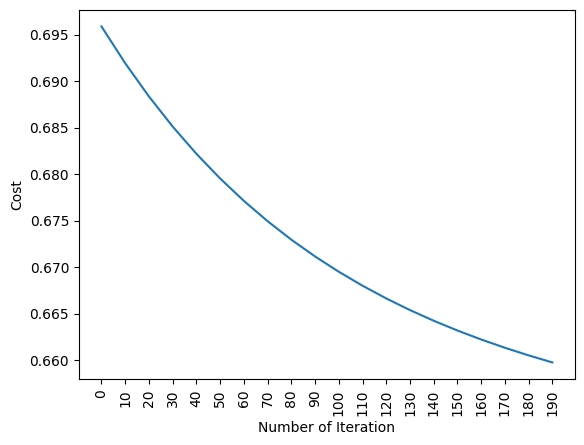

test accuracy: 64.28571428571428 %


In [17]:
logistic_regression(x_train, y_train, x_test, y_test,learning_rate = 0.01, num_iterations = 200)

Cost after iteration 0: 0.695878
Cost after iteration 10: 0.608772
Cost after iteration 20: 0.569602
Cost after iteration 30: 0.547560
Cost after iteration 40: 0.533052
Cost after iteration 50: 0.522396
Cost after iteration 60: 0.514196
Cost after iteration 70: 0.507694
Cost after iteration 80: 0.502420
Cost after iteration 90: 0.498064


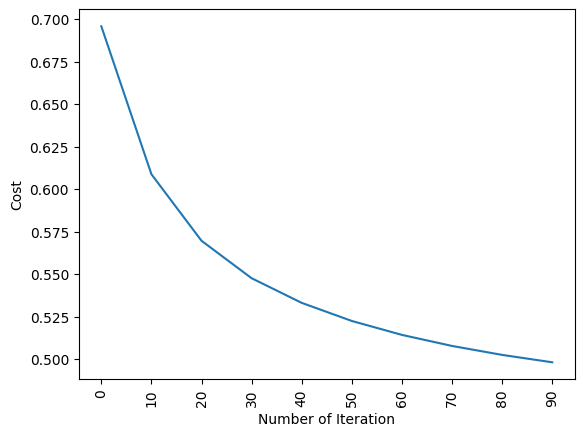

test accuracy: 76.62337662337663 %


In [18]:
logistic_regression(x_train, y_train, x_test, y_test,learning_rate = 4, num_iterations = 100)

With SkLearn

In [14]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(x_train.T,y_train.T)
print("Test Accuracy {}".format(lr.score(x_test.T,y_test.T)))

Test Accuracy 0.7662337662337663
